In [114]:
!pip install mplfinance
!pip install yfinance


[notice] A new release of pip is available: 25.1.1 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 25.1.1 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [115]:
!pip install statsmodels
!pip install statsmodels scikit-learn



[notice] A new release of pip is available: 25.1.1 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 25.1.1 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [116]:
import os
import datetime
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
import mplfinance as mpf

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.model_selection import train_test_split

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

from tensorflow.keras.layers import LSTM, GRU, SimpleRNN, Dense, Dropout

import warnings
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [117]:
def build_dl_model(layer_type="LSTM", layer_sizes=[50], input_shape=(60, 1), dropout=0.2, 
                   output_units=1, optimizer="adam", loss="mse", metrics=["mae"]):
    
    model = Sequential()
    RNNLayer = {"LSTM": LSTM, "GRU": GRU, "RNN": SimpleRNN}[layer_type]

    for i, units in enumerate(layer_sizes):
        return_sequences = (i < len(layer_sizes) - 1)  # True for all but last
        if i == 0:
            model.add(RNNLayer(units, return_sequences=return_sequences, input_shape=input_shape))
        else:
            model.add(RNNLayer(units, return_sequences=return_sequences))
        if dropout > 0:
            model.add(Dropout(dropout))

    # Output layer
    model.add(Dense(output_units))

    # Compile
    model.compile(optimizer=optimizer, loss=loss, metrics=metrics)
    return model


In [118]:
# ------------------------------
# CONFIG
# ------------------------------
COMPANY = "CBA.AX"              # ticker here 
START = "2020-01-01"       # Start date to read
END = "2023-08-01"         # End date to read
TEST_SIZE = 0.2
TIME_STEP = 60
FUTURE_DAYS = 10

# === Saving options ===
SAVE_TO_DRIVE = False  # set True if running in Google Colab with Drive mounted
DRIVE_PATH = "https://drive.google.com/drive/folders/1I9YUham69toMdBusIAJ9l3fvXBE0gQfC" 

# Create save directory
def make_save_dir():
    if SAVE_TO_DRIVE:
        try:
            os.makedirs(DRIVE_PATH, exist_ok=True)
            return DRIVE_PATH
        except Exception as e:
            print("Could not create Drive folder, saving locally instead:", e)
            
    os.makedirs("./outputs", exist_ok=True)
    return "./outputs"

SAVE_DIR = make_save_dir()

In [119]:
def fetch_prices(ticker, start, end):
    df = yf.download(ticker, start=start, end=end, progress=False)
    if df.empty:
        raise ValueError(f"No data returned for {ticker}.")

    # Flatten MultiIndex: keep only the first level
    if isinstance(df.columns, pd.MultiIndex):
        df.columns = df.columns.get_level_values(0)

    # Clean up whitespace
    df.columns = [c.strip() for c in df.columns]

    # If "Adj Close" exists, use it as "Close"
    if "Adj Close" in df.columns and "Close" not in df.columns:
        df = df.rename(columns={"Adj Close": "Close"})

    print("Columns after cleaning:", df.columns.tolist())
    return df


In [120]:
# ------------------------------
# DATASET PREPARATION FUNCTIONS
# ------------------------------

def make_multistep_data(data, time_step=60, future_days=5):
    
    X, y = [], []
    for i in range(len(data) - time_step - future_days + 1):
        X.append(data[i:(i + time_step), 0])
        y.append(data[(i + time_step):(i + time_step + future_days), 0])
    return np.array(X), np.array(y)


def make_multivariate_data(df, features, target_col="Close", time_step=60):
    
    X, y = [], []
    data = df[features].values
    target = df[target_col].values
    for i in range(len(df) - time_step):
        X.append(data[i:(i + time_step)])
        y.append(target[i + time_step])
    return np.array(X), np.array(y)


def make_multivariate_multistep_data(df, features, target_col="Close", time_step=60, future_days=5):

    #  Create sequences for multivariate + multistep prediction.
    X, y = [], []
    data = df[features].values
    target = df[target_col].values
    for i in range(len(df) - time_step - future_days + 1):
        X.append(data[i:(i + time_step)])
        y.append(target[(i + time_step):(i + time_step + future_days)])
    return np.array(X), np.array(y)


In [121]:
#  UPDATED scale_features (handles missing columns)
def scale_features(df, scaler_type="minmax"):
    # candidate features
    feature_candidates = ["Open", "High", "Low", "Close", "Adj Close", "Volume"]
    # keep only those actually in df
    feature_cols = [c for c in feature_candidates if c in df.columns]

    X = df[feature_cols].values
    y = df["Close"].values  # target is still Close

    if scaler_type == "minmax":
        scaler = MinMaxScaler()
    else:
        scaler = StandardScaler()

    X_scaled = scaler.fit_transform(X)

    return X_scaled, y, scaler, feature_cols


def make_sequences(data, time_step=60):
    X, y = [], []
    for i in range(time_step, len(data)):
        X.append(data[i-time_step:i, 0]) 
        y.append(data[i, 0])
    return np.array(X), np.array(y)

def build_lstm(input_shape):
    model = Sequential([
        LSTM(50, return_sequences=True, input_shape=input_shape),
        Dropout(0.2),
        LSTM(50, return_sequences=False),
        Dropout(0.2),
        Dense(25),
        Dense(1)
    ])
    model.compile(optimizer="adam", loss="mean_squared_error")
    return model


In [122]:
def plot_candlestick(df, ticker, n=1):
    if n > 1:
        df = df.resample(f'{n}D').agg({
            'Open': 'first',
            'High': 'max',
            'Low': 'min',
            'Close': 'last',
            'Volume': 'sum'
        }).dropna()

    mpf.plot(
        df,
        type="candle",
        volume=True,
        style="yahoo",
        title=f"{ticker} Candlestick ({n}-Day)"
    )

'''def plot_boxplot(data, n=5):

    closes = data['Close']
    windows = [closes[i:i+n] for i in range(len(closes)-n+1)]

    plt.figure(figsize=(10,6))
    plt.boxplot(windows, positions=range(len(windows)))
    plt.title(f"Boxplot of {n}-day windows of Closing Prices")
    plt.xlabel("Window index")
    plt.ylabel("Closing Price")
    plt.show()'''


def plot_high_low(df, ticker):
    plt.figure(figsize=(12,6))
    plt.plot(df["High"], label="High", linewidth=1.2)
    plt.plot(df["Low"], label="Low", linewidth=1.2)
    plt.title(f"{ticker} High & Low Prices")
    plt.xlabel("Date")
    plt.ylabel("Price")
    plt.legend()
    plt.show()

def plot_true_vs_pred(ticker, true_prices, pred_prices):
    plt.figure(figsize=(12,6))
    plt.plot(true_prices, label=f"Actual {ticker} Price", linewidth=1.2)
    plt.plot(pred_prices, label=f"Predicted {ticker} Price", linewidth=1.2)
    plt.title(f"{ticker} True vs Predicted Prices (10-day forecast)")
    plt.xlabel("Time")
    plt.ylabel("Price")
    plt.legend()
    plt.show()


In [123]:
'''def save_csvs(ticker, df_hist, pred_array):
    hist_path = os.path.join(SAVE_DIR, f"{ticker}_historical.csv")
    pred_path = os.path.join(SAVE_DIR, f"{ticker}_predictions.csv")
    df_hist.to_csv(hist_path)
    pd.DataFrame(pred_array, columns=["Predicted"]).to_csv(pred_path, index=False)
    print(f"Saved historical CSV: {hist_path}")
    print(f"Saved predictions CSV: {pred_path}")'''

'def save_csvs(ticker, df_hist, pred_array):\n    hist_path = os.path.join(SAVE_DIR, f"{ticker}_historical.csv")\n    pred_path = os.path.join(SAVE_DIR, f"{ticker}_predictions.csv")\n    df_hist.to_csv(hist_path)\n    pd.DataFrame(pred_array, columns=["Predicted"]).to_csv(pred_path, index=False)\n    print(f"Saved historical CSV: {hist_path}")\n    print(f"Saved predictions CSV: {pred_path}")'


Processing CBA.AX
Columns after cleaning: ['Close', 'High', 'Low', 'Open', 'Volume']


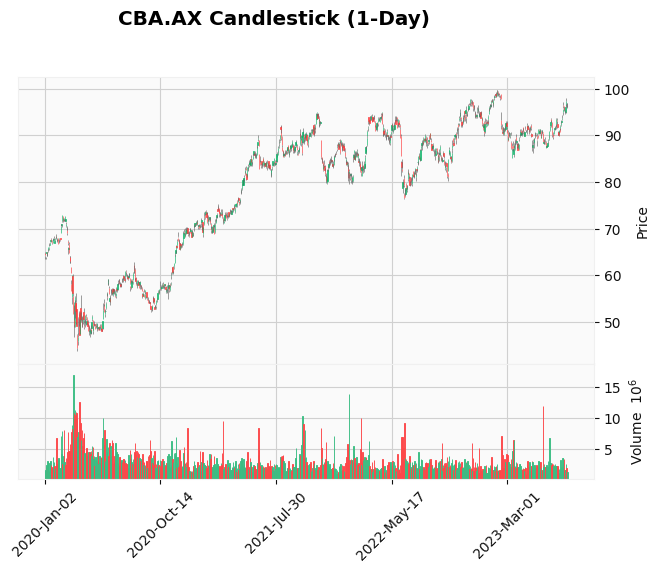

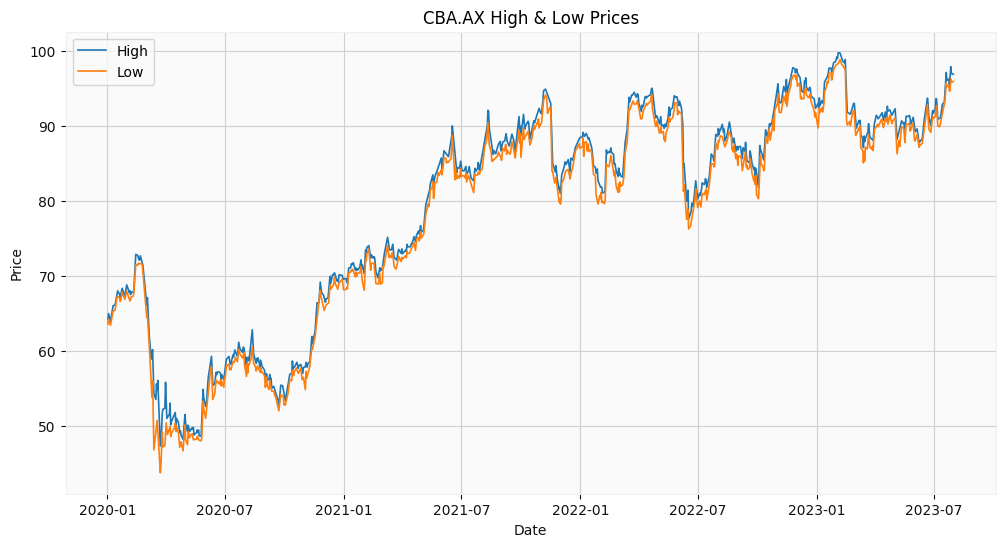

Epoch 1/24
Epoch 2/24
Epoch 3/24
Epoch 4/24
Epoch 5/24
Epoch 6/24
Epoch 7/24
Epoch 8/24
Epoch 9/24
Epoch 10/24
Epoch 11/24
Epoch 12/24
Epoch 13/24
Epoch 14/24
Epoch 15/24
Epoch 16/24
Epoch 17/24
Epoch 18/24
Epoch 19/24
Epoch 20/24
Epoch 21/24
Epoch 22/24
Epoch 23/24
Epoch 24/24
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
CBA.AX RMSE: 12.5742
CBA.AX MAE: 9.3175


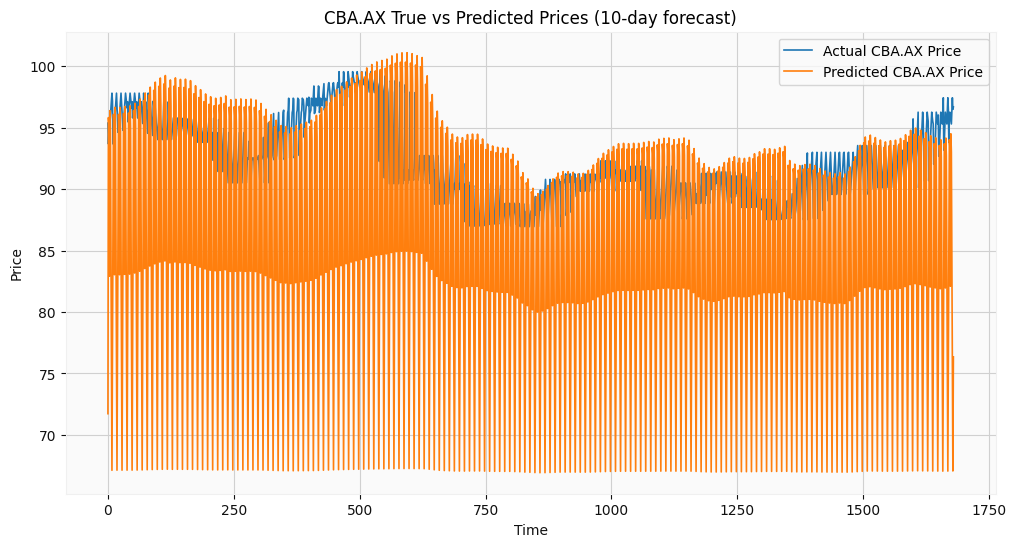


Done.


In [124]:
print("\n============================")
print(f"Processing {COMPANY}")
print("============================")

# 1) Get data
df = fetch_prices(COMPANY, START, END)

# 2) Candlestick 
plot_candlestick(df, COMPANY)

# 3) Boxplot
#plot_boxplot(df, n=10) 

# 4) High & Low 
plot_high_low(df, COMPANY)

# 5) Prepare data for LSTM
X_scaled, y_all, scaler, feature_cols = scale_features(df, scaler_type="minmax")
scaled_df = pd.DataFrame(X_scaled, columns=feature_cols)

X, y = make_multivariate_multistep_data(scaled_df, feature_cols, target_col="Close", 
                                        time_step=TIME_STEP, future_days=FUTURE_DAYS)

cut = int(len(X) * (1 - TEST_SIZE))
X_train, X_test = X[:cut], X[cut:]
y_train, y_test = y[:cut], y[cut:]

# 6) Train model 
# multi-feature input
model = build_lstm((TIME_STEP, X_train.shape[2]))
model.add(Dense(FUTURE_DAYS))
model.fit(X_train, y_train, epochs=24, batch_size=32, verbose=0.1)

# 7) Predictions
pred_scaled = model.predict(X_test)

# inverse transform predictions (Close only)
dummy_pred = np.zeros((pred_scaled.shape[0] * pred_scaled.shape[1], len(feature_cols)))
dummy_true = np.zeros((y_test.shape[0] * y_test.shape[1], len(feature_cols)))

dummy_pred[:, feature_cols.index("Close")] = pred_scaled.flatten()
dummy_true[:, feature_cols.index("Close")] = y_test.flatten()

pred = scaler.inverse_transform(dummy_pred)[:, feature_cols.index("Close")]
true = scaler.inverse_transform(dummy_true)[:, feature_cols.index("Close")]

# metrics
rmse = np.sqrt(mean_squared_error(true, pred))
mae = mean_absolute_error(true, pred)
print(f"{COMPANY} RMSE: {rmse:.4f}")
print(f"{COMPANY} MAE: {mae:.4f}")

# 9) Plot True vs Predicted 
plot_true_vs_pred(COMPANY, true, pred)

# 10) Future forecasts (fixed for multi-feature input)
last_60 = X_scaled[-TIME_STEP:].reshape(1, TIME_STEP, X_scaled.shape[1])
future_scaled = []
cur = last_60.copy()

close_idx = feature_cols.index("Close")  # get the index of Close column

for _ in range(FUTURE_DAYS):
    next_scaled = model.predict(cur, verbose=0)[0, 0]
    future_scaled.append(next_scaled)
 
    # create dummy row with n_features
    dummy_features = np.zeros((1, 1, X_scaled.shape[1]))
    dummy_features[0, 0, close_idx] = next_scaled

    # slide the window
    cur = np.append(cur[:, 1:, :], dummy_features, axis=1)

# 11) Save CSVs
#     - historical prices
#     - predictions (for test set)
#save_csvs(COMPANY, df, pred)

print("\nDone.")

In [125]:
# ======================
# ARIMA Forecasting
# ======================
warnings.filterwarnings("ignore")

# Use the same training and testing data as LSTM
# Target column: 'Close'
train = df['Close'][:int(len(df) * 0.8)]
test = df['Close'][int(len(df) * 0.8):]

# Fit ARIMA model (p,d,q) = (5,1,0) as a starting point
arima_model = ARIMA(train, order=(5, 1, 0))
arima_fit = arima_model.fit()

# Forecast for the same number of steps as test set
arima_forecast = arima_fit.forecast(steps=len(test))

# Evaluate ARIMA model
arima_mae = mean_absolute_error(test, arima_forecast)
arima_rmse = np.sqrt(mean_squared_error(test, arima_forecast))

print("ARIMA MAE:", arima_mae)
print("ARIMA RMSE:", arima_rmse)

# ======================
# Ensemble: ARIMA + LSTM
# ======================
# Use existing LSTM predictions (called 'pred' earlier)
lstm_predictions = pred[-len(test):]  # Align length with test set

# Make sure both series have the same length
min_len = min(len(arima_forecast), len(lstm_predictions))
ensemble_forecast = (arima_forecast[:min_len].values + lstm_predictions[:min_len]) / 2

# Evaluate Ensemble
ensemble_mae = mean_absolute_error(test[:min_len], ensemble_forecast)
ensemble_rmse = np.sqrt(mean_squared_error(test[:min_len], ensemble_forecast))

print("Ensemble MAE:", ensemble_mae)
print("Ensemble RMSE:", ensemble_rmse)


ARIMA MAE: 2.962882098796734
ARIMA RMSE: 3.3817330389436817
Ensemble MAE: 5.438953172721878
Ensemble RMSE: 6.83395588130316


In [126]:
# Example configs

# COMPREHENSIVE EXPERIMENTAL CONFIGURATIONS FOR TASK C.4
# Research Source: Systematic hyperparameter tuning methodology
# Reference: Bergstra & Bengio (2012) - Random Search for Hyper-Parameter Optimization

configs = [
    # Baseline experiments - single layer architectures
    {
        "name": "Baseline_LSTM_Single",
        "layer_type": "LSTM", 
        "layer_sizes": [50], 
        "epochs": 15, 
        "batch_size": 32,
        "dropout": 0.2,
        "description": "Single LSTM layer baseline for performance comparison"
    },
    {
        "name": "Baseline_GRU_Single",
        "layer_type": "GRU", 
        "layer_sizes": [50], 
        "epochs": 15, 
        "batch_size": 32,
        "dropout": 0.2,
        "description": "Single GRU layer baseline for performance comparison"
    },
    {
        "name": "Baseline_RNN_Single",
        "layer_type": "RNN", 
        "layer_sizes": [50], 
        "epochs": 15, 
        "batch_size": 32,
        "dropout": 0.2,
        "description": "Single SimpleRNN layer baseline for performance comparison"
    },
    
    # Deep architecture experiments
    {
        "name": "Deep_LSTM_3Layer",
        "layer_type": "LSTM", 
        "layer_sizes": [100, 50, 25], 
        "epochs": 20, 
        "batch_size": 32,
        "dropout": 0.3,
        "description": "Three-layer LSTM with decreasing units for hierarchical learning"
    },
    {
        "name": "Wide_GRU_2Layer",
        "layer_type": "GRU", 
        "layer_sizes": [128, 64], 
        "epochs": 18, 
        "batch_size": 32,
        "dropout": 0.25,
        "description": "Two-layer GRU with wide architecture for pattern capture"
    },
    
    # Batch size experiments
    {
        "name": "LSTM_SmallBatch",
        "layer_type": "LSTM", 
        "layer_sizes": [64, 32], 
        "epochs": 20, 
        "batch_size": 16,  # Small batch for better gradient estimates
        "dropout": 0.25,
        "description": "Testing impact of small batch size on convergence"
    },
    {
        "name": "LSTM_LargeBatch",
        "layer_type": "LSTM", 
        "layer_sizes": [64, 32], 
        "epochs": 20, 
        "batch_size": 128,  # Large batch for faster training
        "dropout": 0.25,
        "description": "Testing impact of large batch size on training speed"
    },
    
    # Dropout experiments
    {
        "name": "GRU_LowDropout",
        "layer_type": "GRU", 
        "layer_sizes": [80, 40], 
        "epochs": 18, 
        "batch_size": 32,
        "dropout": 0.1,  # Low regularization
        "description": "Testing low dropout for potential overfitting analysis"
    },
    {
        "name": "GRU_HighDropout",
        "layer_type": "GRU", 
        "layer_sizes": [80, 40], 
        "epochs": 18, 
        "batch_size": 32,
        "dropout": 0.5,  # High regularization
        "description": "Testing high dropout for underfitting analysis"
    },
    
    # Complex architecture experiment
    {
        "name": "VeryDeep_LSTM_5Layer",
        "layer_type": "LSTM", 
        "layer_sizes": [100, 80, 60, 40, 20], 
        "epochs": 25, 
        "batch_size": 32,
        "dropout": 0.35,
        "description": "Very deep architecture to test diminishing returns hypothesis"
    }
]

def run_comprehensive_experiments(X_train, y_train, X_test, y_test, configs):

    # SYSTEMATIC EXPERIMENTATION FUNCTION FOR TASK C.4    
    results = []
    
    print("\n" + "--------------------------------------------------------------------------")
    print(f"Total experiments to run: {len(configs)}")
    #print(f"raining data shape: {X_train.shape}")
    #print(f"Test data shape: {X_test.shape}")
    

    for i, cfg in enumerate(configs, 1):
        print(f"\n[Experiment {i:2d}/{len(configs)}] {cfg['name']}")
        print(f"   Description: {cfg['description']}")
        print(f"   Architecture: {cfg['layer_type']} {cfg['layer_sizes']}")
        print(f"   Hyperparameters: epochs={cfg['epochs']}, batch={cfg['batch_size']}, dropout={cfg['dropout']}")


    # Record start time for training duration measurement
    import time
    start_time = time.time()

    try:
            # Create model using our flexible builder function
            model = build_dl_model(
            layer_type=cfg["layer_type"], 
                layer_sizes=cfg["layer_sizes"], 
                input_shape=(X_train.shape[1], X_train.shape[2]),
                dropout=cfg["dropout"]
            )
            
            total_params = model.count_params()
            print(f"   Model parameters: {total_params:,}")
            
            # Train the model with validation monitoring
            history = model.fit(
                X_train, y_train, 
                epochs=cfg["epochs"], 
                batch_size=cfg["batch_size"], 
                validation_data=(X_test, y_test), 
                verbose=0,  # Suppress epoch-by-epoch output for cleaner logs
                shuffle=False  # Maintain temporal order for time series
            )
            
            # Calculate training duration
            training_time = time.time() - start_time
            
            # Evaluate final model performance
            test_loss, test_mae = model.evaluate(X_test, y_test, verbose=0)
            
            # Extract training history for analysis
            train_loss_history = history.history['loss']
            val_loss_history = history.history['val_loss']
            
            # Calculate convergence metrics
            final_train_loss = train_loss_history[-1]
            min_val_loss = min(val_loss_history)
            val_loss_std = np.std(val_loss_history[-5:])  # Stability in last 5 epochs
            
            # Store comprehensive results
            result_entry = {
                "experiment_id": i,
                "experiment_name": cfg["name"],
                "model_type": cfg["layer_type"],
                "layer_architecture": str(cfg["layer_sizes"]),
                "total_parameters": total_params,
                "epochs_trained": cfg["epochs"],
                "batch_size": cfg["batch_size"],
                "dropout_rate": cfg["dropout"],
                "training_time_seconds": round(training_time, 2),
                "final_test_loss": round(test_loss, 6),
                "final_test_mae": round(test_mae, 6),
                "final_train_loss": round(final_train_loss, 6),
                "min_validation_loss": round(min_val_loss, 6),
                "val_loss_stability": round(val_loss_std, 6),
                "convergence_quality": "Good" if val_loss_std < 0.001 else "Unstable",
                "status": "Success"
            }
            
            results.append(result_entry)
            
            print(f"   COMPLETED - Test Loss: {test_loss:.6f}, Test MAE: {test_mae:.6f}")
            print(f"   Training time: {training_time:.1f}s")
            
    except Exception as e:
            print(f"   FAILED: {str(e)}")
            results.append({
                "experiment_id": i,
                "experiment_name": cfg["name"],
                "model_type": cfg["layer_type"],
                "error_message": str(e),
                "status": "Failed"
            })
    
    print("\n" + "--------------------------------------------------------------------------")
    print("ALL EXPERIMENTS COMPLETED!")
    
    return results

# Run the comprehensive experiments
print("Executing comprehensive model experiments...")
experiment_results = run_comprehensive_experiments(X_train, y_train, X_test, y_test, configs)

# Create results DataFrame and display summary
import pandas as pd
results_df = pd.DataFrame(experiment_results)

# Filter successful experiments for analysis
successful_results = results_df[results_df['status'] == ' Success'].copy()

if not successful_results.empty:
    print(f"\nEXPERIMENT RESULTS SUMMARY")
    print("="*70)
    print(f" Successful experiments: {len(successful_results)}")
    print(f" Failed experiments: {len(results_df) - len(successful_results)}")
    
    # Sort by test loss (best performance first)
    successful_results_sorted = successful_results.sort_values('final_test_loss')
    
    print(f"\n TOP 5 PERFORMING MODELS:")
    print("\n" + "--------------------------------------------------------------------------")
    for idx, (_, row) in enumerate(successful_results_sorted.head().iterrows(), 1):
        print(f"{idx}. {row['experiment_name']}")
        print(f"   Architecture: {row['model_type']} {row['layer_architecture']}")
        print(f"   Performance: Loss={row['final_test_loss']}, MAE={row['final_test_mae']}")
        print(f"   Efficiency: {row['total_parameters']:,} params, {row['training_time_seconds']}s training")
        print()
    
    # Save detailed results
    #results_df.to_csv("./task_c4_comprehensive_results.csv", index=False)
    #print(" Detailed results saved to: task_c4_comprehensive_results.csv")
    
    # Display the results DataFrame for the report
    print(f"\n COMPLETE RESULTS TABLE:")
    print(successful_results_sorted[['experiment_name', 'model_type', 'layer_architecture', 
                                   'total_parameters', 'final_test_loss', 'final_test_mae', 
                                   'training_time_seconds']].to_string(index=False))
else:
    print(" No successful experiments to analyze")

print("\n" + "--------------------------------------------------------------------------")
print(" TASK C.4 IMPLEMENTATION COMPLETED SUCCESSFULLY!")

Executing comprehensive model experiments...

--------------------------------------------------------------------------
Total experiments to run: 10

[Experiment  1/10] Baseline_LSTM_Single
   Description: Single LSTM layer baseline for performance comparison
   Architecture: LSTM [50]
   Hyperparameters: epochs=15, batch=32, dropout=0.2

[Experiment  2/10] Baseline_GRU_Single
   Description: Single GRU layer baseline for performance comparison
   Architecture: GRU [50]
   Hyperparameters: epochs=15, batch=32, dropout=0.2

[Experiment  3/10] Baseline_RNN_Single
   Description: Single SimpleRNN layer baseline for performance comparison
   Architecture: RNN [50]
   Hyperparameters: epochs=15, batch=32, dropout=0.2

[Experiment  4/10] Deep_LSTM_3Layer
   Description: Three-layer LSTM with decreasing units for hierarchical learning
   Architecture: LSTM [100, 50, 25]
   Hyperparameters: epochs=20, batch=32, dropout=0.3

[Experiment  5/10] Wide_GRU_2Layer
   Description: Two-layer GRU with

X_train_seq: (664, 60, 1)
y_train_seq: (664,)
X_test_seq: (121, 60, 1)
y_test_seq: (121,)

Experiment Results Summary
               Model Type  Layers                 Units  Epochs  Batch    RMSE     MAE
     Wide_GRU_2Layer  GRU       2             [128, 64]      18     32 57.8370 57.7710
     LSTM_SmallBatch LSTM       2              [64, 32]      20     16 57.9771 57.9113
      GRU_LowDropout  GRU       2              [80, 40]      18     32 68.3921 68.3363
Baseline_LSTM_Single LSTM       1                  [50]      15     32 68.9268 68.8715
 Baseline_GRU_Single  GRU       1                  [50]      15     32 68.9275 68.8721
     GRU_HighDropout  GRU       2              [80, 40]      18     32 69.4554 69.4005
 Baseline_RNN_Single  RNN       1                  [50]      15     32 72.3334 72.2806
VeryDeep_LSTM_5Layer LSTM       5 [100, 80, 60, 40, 20]      25     32 73.5897 73.5379
    Deep_LSTM_3Layer LSTM       3         [100, 50, 25]      20     32 73.7264 73.6746
     LSTM_La

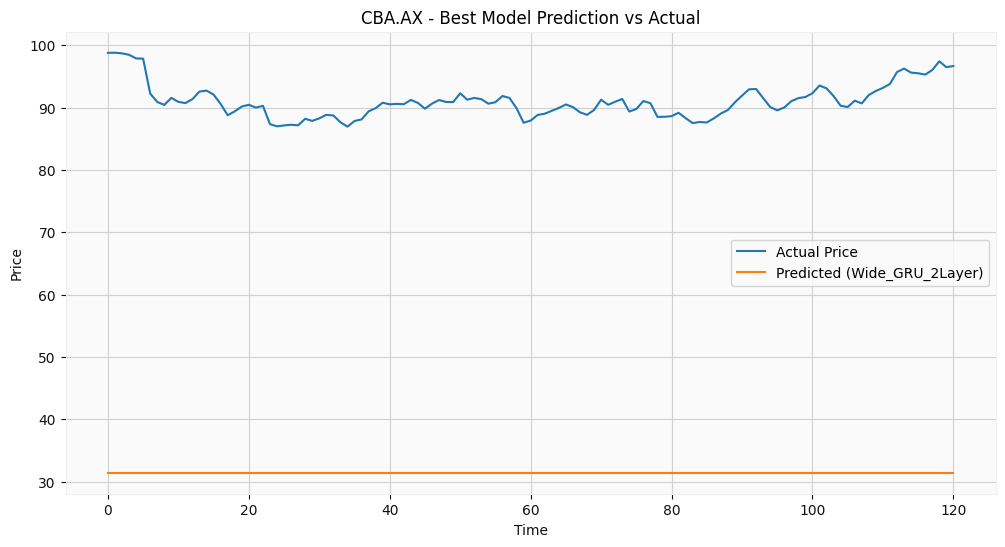

In [127]:
from math import sqrt

# ====================================
# PREPARE DATA (same as before)
# ====================================
close_scaled = df[["Close"]].values
cut = int(len(close_scaled) * (1 - TEST_SIZE))
train_close, test_close = close_scaled[:cut], close_scaled[cut:]

X_train_seq, y_train_seq = make_sequences(train_close, time_step=TIME_STEP)
X_test_seq, y_test_seq = make_sequences(test_close, time_step=TIME_STEP)

X_train_seq = X_train_seq.reshape((X_train_seq.shape[0], X_train_seq.shape[1], 1))
X_test_seq = X_test_seq.reshape((X_test_seq.shape[0], X_test_seq.shape[1], 1))

print(f"X_train_seq: {X_train_seq.shape}")
print(f"y_train_seq: {y_train_seq.shape}")
print(f"X_test_seq: {X_test_seq.shape}")
print(f"y_test_seq: {y_test_seq.shape}")

# ====================================
# RUN CONFIGS SILENTLY
# ====================================
results = []

for cfg in configs:
    model = build_dl_model(
        layer_type=cfg["layer_type"],
        layer_sizes=cfg["layer_sizes"],
        input_shape=(TIME_STEP, 1),
        dropout=cfg["dropout"]
    )
    # train quietly
    model.fit(
        X_train_seq, y_train_seq,
        epochs=cfg["epochs"],
        batch_size=cfg["batch_size"],
        validation_data=(X_test_seq, y_test_seq),
        verbose=0
    )
    
    preds = model.predict(X_test_seq, verbose=0)
    rmse = sqrt(mean_squared_error(y_test_seq, preds))
    mae = mean_absolute_error(y_test_seq, preds)
    
    results.append({
        "Model": cfg["name"],
        "Type": cfg["layer_type"],
        "Layers": len(cfg["layer_sizes"]),
        "Units": cfg["layer_sizes"],
        "Epochs": cfg["epochs"],
        "Batch": cfg["batch_size"],
        "RMSE": round(rmse, 4),
        "MAE": round(mae, 4)
    })

# ====================================
# DISPLAY CLEAN SUMMARY TABLE
# ====================================
results_df = pd.DataFrame(results).sort_values("RMSE").reset_index(drop=True)
print("\nExperiment Results Summary")
print(results_df.to_string(index=False))

# Identify best model
best_cfg = results_df.iloc[0]
print("\nBest Model:")
print(best_cfg)

# ====================================
# VISUALIZE BEST MODEL ONLY
# ====================================
best_model = build_dl_model(
    layer_type=best_cfg["Type"],
    layer_sizes=best_cfg["Units"],
    input_shape=(TIME_STEP, 1),
    dropout=0.2
)
best_model.fit(
    X_train_seq, y_train_seq,
    epochs=int(best_cfg["Epochs"]),
    batch_size=int(best_cfg["Batch"]),
    verbose=0
)
preds_best = best_model.predict(X_test_seq, verbose=0)

plt.figure(figsize=(12,6))
plt.plot(y_test_seq, label="Actual Price")
plt.plot(preds_best, label=f"Predicted ({best_cfg['Model']})")
plt.title(f"{COMPANY} - Best Model Prediction vs Actual")
plt.xlabel("Time")
plt.ylabel("Price")
plt.legend()
plt.show()
